<a href="https://colab.research.google.com/github/L1ght6/LabsKSVD/blob/main/%D0%93%D0%BE%D1%80%D0%B0_%D0%9B%D0%A04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 4

---

Гора Р.В ФІТ3-9

---

https://colab.research.google.com/drive/1ogJ-HzW93ytFnJIQ6__R_3bECiOXHhGF?usp=sharing

---
https://github.com/L1ght6/LabsKSVD/blob/main/%D0%93%D0%BE%D1%80%D0%B0_%D0%9B%D0%A04.ipynb


Завдання 1

1. Імпорт бібліотек та завантаження датасету

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Налаштування стилю графіків
sns.set_theme(style="whitegrid")

# Завантаження датасету
df_museum = pd.read_csv('Museum_Visitors (2).csv')

# Виведення перших 5 рядків
display(df_museum.head())

,Month,America Tropical Interpretive Center,Avila Adobe,Chinese American Museum,Gateway to Nature Center,Firehouse Museum,Hellman Quon,IAMLA,Pico House,Visitor Center/ El Tranquilo Gallery,Museum of Social Justice,Biscailuz Gallery/ PK Outdoor Exhibit
0,01/01/2014 12:00:00 AM,6602,24778,1581,NaN,4486,0.0,NaN,2204.0,2961.0,NaN,NaN
1,02/01/2014 12:00:00 AM,5029,18976,1785,NaN,4172,0.0,NaN,1330.0,2276.0,NaN,NaN
2,03/01/2014 12:00:00 AM,8129,25231,3229,NaN,7082,70.0,NaN,4320.0,3116.0,NaN,NaN
3,04/01/2014 12:00:00 AM,2824,26989,2129,NaN,6756,250.0,NaN,3277.0,2808.0,NaN,NaN
4,05/01/2014 12:00:00 AM,10694,36883,3676,NaN,10858,135.0,NaN,4122.0,3987.0,NaN,NaN


2: Попередній аналіз даних

In [5]:
print("Розмір датасету")
print(f"Рядків: {df_museum.shape[0]}, Стовпців: {df_museum.shape[1]}\n")

print("Типи даних")
print(df_museum.dtypes)
print("\n Кількість пропусків")
print(df_museum.isnull().sum())

Розмір датасету
Рядків: 85, Стовпців: 12

Типи даних
Month                                    datetime64[ns]
America Tropical Interpretive Center              int64
Avila Adobe                                       int64
Chinese American Museum                           int64
Gateway to Nature Center                        float64
Firehouse Museum                                  int64
Hellman Quon                                    float64
IAMLA                                           float64
Pico House                                      float64
Visitor Center/ El Tranquilo Gallery            float64
Museum of Social Justice                        float64
Biscailuz Gallery/ PK Outdoor Exhibit           float64
dtype: object

 Кількість пропусків
Month                                     0
America Tropical Interpretive Center      0
Avila Adobe                               0
Chinese American Museum                   0
Gateway to Nature Center                 53
Firehouse Museum   

Перевірка на дублікати

In [3]:
duplicates_count = df_museum.duplicated().sum()
print(f"Кількість дублікатів: {duplicates_count}")

if duplicates_count > 0:
    df_museum = df_museum.drop_duplicates()

print(f"Розмір таблиці після перевірки на дублікати: {df_museum.shape}")

Кількість дублікатів: 0
Розмір таблиці після перевірки на дублікати: (85, 12)


Інформація про роки

In [4]:
# Перетворення колонки Month у тип datetime
df_museum['Month'] = pd.to_datetime(df_museum['Month'])

years_covered = df_museum['Month'].dt.year.unique()
print("Датасет містить інформацію про такі роки:")
print(sorted(years_covered))

Датасет містить інформацію про такі роки:
[np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)]


/tmp/ipykernel_5887/219583802.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_museum['Month'] = pd.to_datetime(df_museum['Month'])


Перейменування стовпців

In [6]:
# Заміна великих літер на маленькі, пробілів та інших символів на підкреслення
df_museum.columns = [re.sub(r'[^a-z0-9]', '_', col.lower().strip()).strip('_') for col in df_museum.columns]
df_museum.columns = [re.sub(r'_+', '_', col) for col in df_museum.columns]

# Перейменування стовпця 'month' на 'date'
df_museum.rename(columns={'month': 'date'}, inplace=True)

print("Оновлені назви стовпців:")
print(df_museum.columns.tolist())

Оновлені назви стовпців:
['date', 'america_tropical_interpretive_center', 'avila_adobe', 'chinese_american_museum', 'gateway_to_nature_center', 'firehouse_museum', 'hellman_quon', 'iamla', 'pico_house', 'visitor_center_el_tranquilo_gallery', 'museum_of_social_justice', 'biscailuz_gallery_pk_outdoor_exhibit']


Обчислення середньої кількості відвідувачів

In [7]:
print("Середня кількість відвідувачів для кожного музею за весь період:\n")
numeric_cols = df_museum.select_dtypes(include=[np.number]).columns
mean_visitors = df_museum[numeric_cols].mean()
print(mean_visitors.round(2))

Середня кількість відвідувачів для кожного музею за весь період:

america_tropical_interpretive_center     5637.69
avila_adobe                             19904.95
chinese_american_museum                  2359.12
gateway_to_nature_center                 1247.38
firehouse_museum                         5286.78
hellman_quon                              353.46
iamla                                     882.61
pico_house                               1329.71
visitor_center_el_tranquilo_gallery      2634.80
museum_of_social_justice                 2125.97
biscailuz_gallery_pk_outdoor_exhibit     1088.62
dtype: float64


Мінімальна та максимальна кількість відвідувачів у 2018 році

In [8]:
df_2018 = df_museum[df_museum['date'].dt.year == 2018]

print("--- Мінімальна кількість відвідувачів у 2018 році ---")
print(df_2018[numeric_cols].min())

print("\n--- Максимальна кількість відвідувачів у 2018 році ---")
print(df_2018[numeric_cols].max())

--- Мінімальна кількість відвідувачів у 2018 році ---
america_tropical_interpretive_center     3180.0
avila_adobe                             14718.0
chinese_american_museum                  2078.0
gateway_to_nature_center                    NaN
firehouse_museum                         3306.0
hellman_quon                                NaN
iamla                                     965.0
pico_house                                185.0
visitor_center_el_tranquilo_gallery         NaN
museum_of_social_justice                 2332.0
biscailuz_gallery_pk_outdoor_exhibit      349.0
dtype: float64

--- Максимальна кількість відвідувачів у 2018 році ---
america_tropical_interpretive_center     5837.0
avila_adobe                             25173.0
chinese_american_museum                  4960.0
gateway_to_nature_center                    NaN
firehouse_museum                         8013.0
hellman_quon                                NaN
iamla                                    1601.0
pico_house 

Місяці з найвищою і найнижчою відвідуваністю у 2015 році

In [9]:
df_2015 = df_museum[df_museum['date'].dt.year == 2015].copy()
df_2015['total_visitors'] = df_2015[numeric_cols].sum(axis=1)

highest_month_idx = df_2015['total_visitors'].idxmax()
lowest_month_idx = df_2015['total_visitors'].idxmin()

# Форматуємо дату для виведення назви місяця (%B)
highest_month = df_2015.loc[highest_month_idx, 'date'].strftime('%B')
lowest_month = df_2015.loc[lowest_month_idx, 'date'].strftime('%B')

print(f"Місяць з найвищою відвідуваністю у 2015 році: {highest_month}")
print(f"Місяць з найнижчою відвідуваністю у 2015 році: {lowest_month}")

Місяць з найвищою відвідуваністю у 2015 році: May
Місяць з найнижчою відвідуваністю у 2015 році: February


Порівняння відвідувачів "Avila Adobe" влітку та взимку 2018 року

In [10]:
summer_months = [6, 7, 8]
winter_months = [12, 1, 2] # Грудень, Січень, Лютий

df_2018_summer = df_2018[df_2018['date'].dt.month.isin(summer_months)]
df_2018_winter = df_2018[df_2018['date'].dt.month.isin(winter_months)]

summer_visitors = df_2018_summer['avila_adobe'].sum()
winter_visitors = df_2018_winter['avila_adobe'].sum()

print(f"Кількість відвідувачів Avila Adobe влітку 2018: {summer_visitors}")
print(f"Кількість відвідувачів Avila Adobe взимку 2018: {winter_visitors}")

if summer_visitors > winter_visitors:
    print("Влітку відвідувачів було більше.")
else:
    print("Взимку відвідувачів було більше.")

Кількість відвідувачів Avila Adobe влітку 2018: 66122
Кількість відвідувачів Avila Adobe взимку 2018: 48705
Влітку відвідувачів було більше.


Кореляція між відвідувачами та датами у 2016 році

In [11]:
df_2016 = df_museum[df_museum['date'].dt.year == 2016].copy()

# Щоб знайти кореляцію з датами, конвертуємо їх у числовий формат (ordinal)
df_2016['date_ordinal'] = df_2016['date'].apply(lambda x: x.toordinal())

print("Кореляція між кількістю відвідувачів та перебігом часу (датами) у 2016 році:\n")
correlation_2016 = df_2016[['date_ordinal'] + list(numeric_cols)].corr()['date_ordinal']
print(correlation_2016.drop('date_ordinal').round(3))

Кореляція між кількістю відвідувачів та перебігом часу (датами) у 2016 році:

america_tropical_interpretive_center   -0.228
avila_adobe                             0.060
chinese_american_museum                -0.415
gateway_to_nature_center                  NaN
firehouse_museum                       -0.202
hellman_quon                            1.000
iamla                                  -0.554
pico_house                              0.554
visitor_center_el_tranquilo_gallery    -0.739
museum_of_social_justice                  NaN
biscailuz_gallery_pk_outdoor_exhibit   -0.124
Name: date_ordinal, dtype: float64


Візуалізація даних

1: Лінійний графік (відвідуваність Avila Adobe з часом)

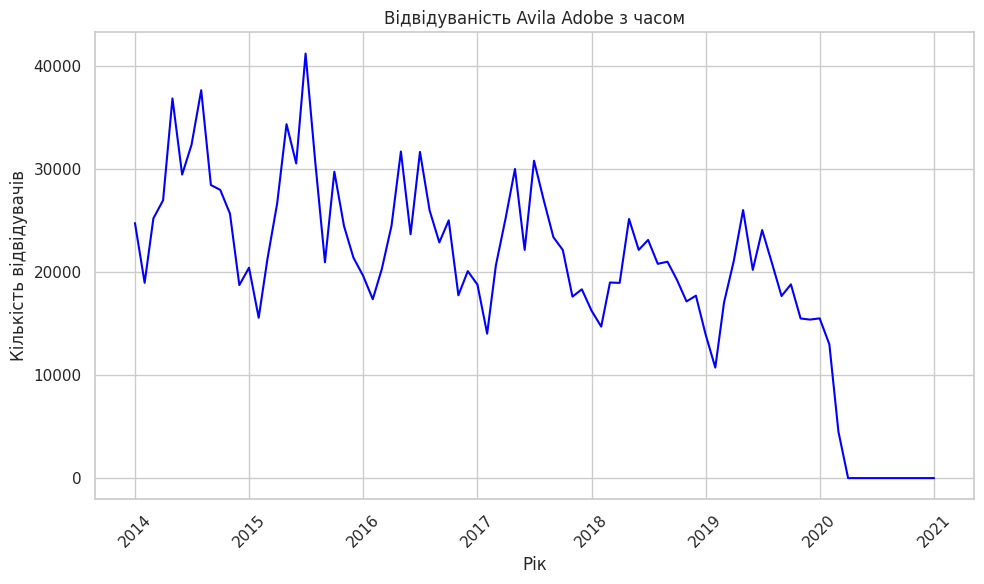

In [13]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_museum, x='date', y='avila_adobe', color='blue')
plt.title('Відвідуваність Avila Adobe з часом')
plt.xlabel('Рік')
plt.ylabel('Кількість відвідувачів')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

2. Boxplot (розподіл відвідувачів Chinese American Museum по роках)

/tmp/ipykernel_5887/1134411193.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_museum, x='year', y='chinese_american_museum', palette='Set2')


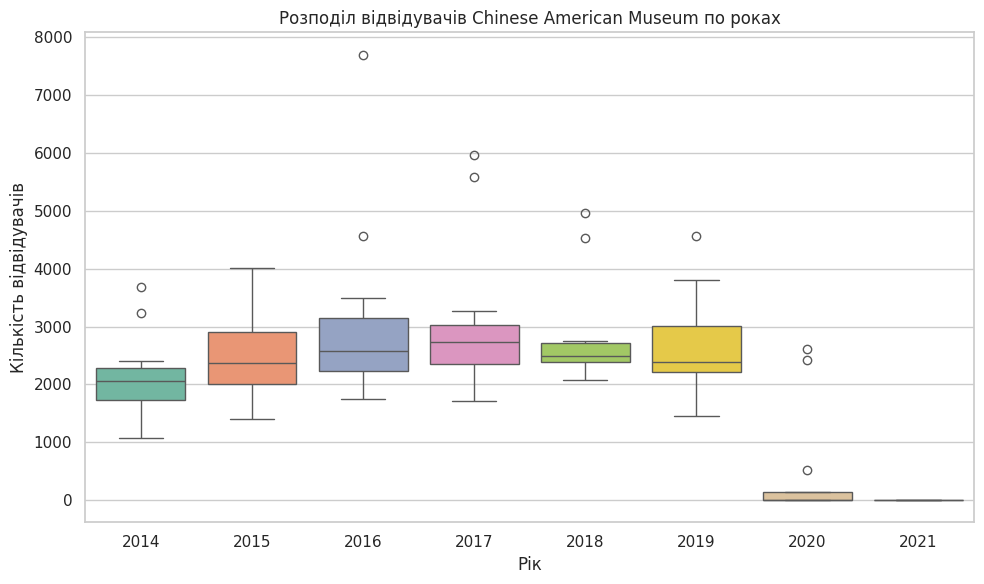

In [14]:
plt.figure(figsize=(10, 6))
# Створюємо колонку з роком, якщо її ще немає
df_museum['year'] = df_museum['date'].dt.year

sns.boxplot(data=df_museum, x='year', y='chinese_american_museum', palette='Set2')
plt.title('Розподіл відвідувачів Chinese American Museum по роках')
plt.xlabel('Рік')
plt.ylabel('Кількість відвідувачів')
plt.tight_layout()
plt.show()

3. Heatmap (кореляція між музеями)

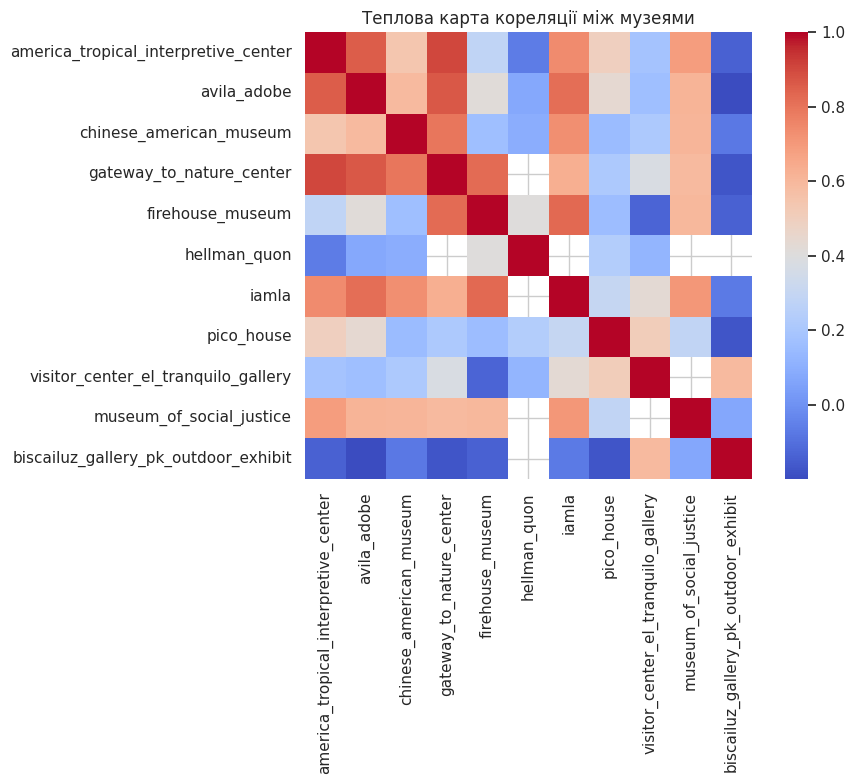

In [15]:
plt.figure(figsize=(10, 8))
# Розраховуємо матрицю кореляції лише для числових колонок
numeric_cols = df_museum.select_dtypes(include=[np.number]).columns
# Відкидаємо колонки 'date_ordinal' та 'year', якщо вони є, щоб дивитися тільки на музеї
museum_cols = [col for col in numeric_cols if col not in ['date_ordinal', 'year']]
corr = df_museum[museum_cols].corr()

sns.heatmap(data=corr, annot=False, cmap='coolwarm', cbar=True, square=True)
plt.title('Теплова карта кореляції між музеями')
plt.tight_layout()
plt.show()

4. Histogram (розподіл кількості відвідувачів Gateway to Nature Center)

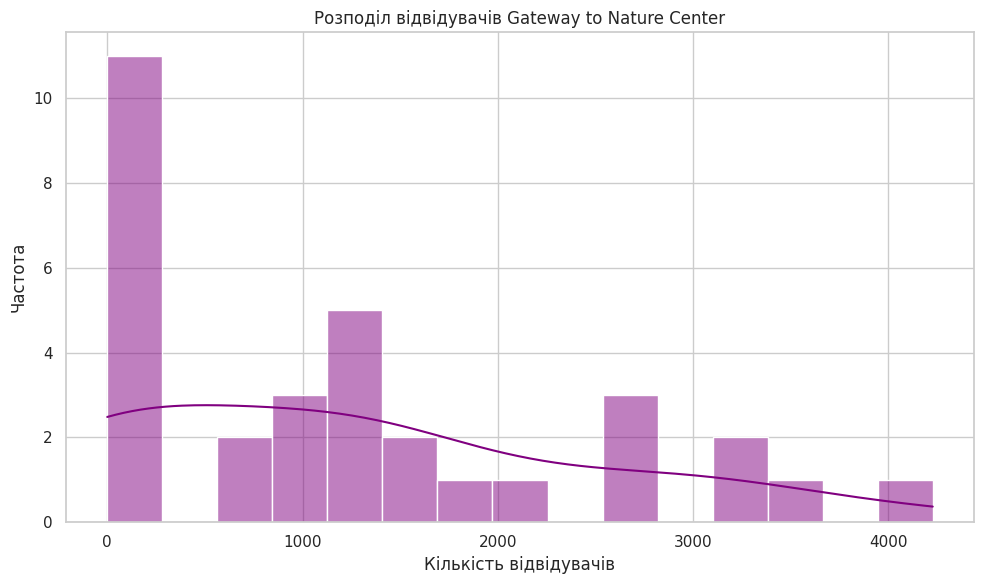

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_museum, x='gateway_to_nature_center', bins=15, kde=True, color='purple')
plt.title('Розподіл відвідувачів Gateway to Nature Center')
plt.xlabel('Кількість відвідувачів')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

5: Barplot (середня кількість відвідувачів по музеях за всі роки)

/tmp/ipykernel_5887/187957430.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mean_visitors_df, x='mean_visitors', y='museum', palette='viridis')


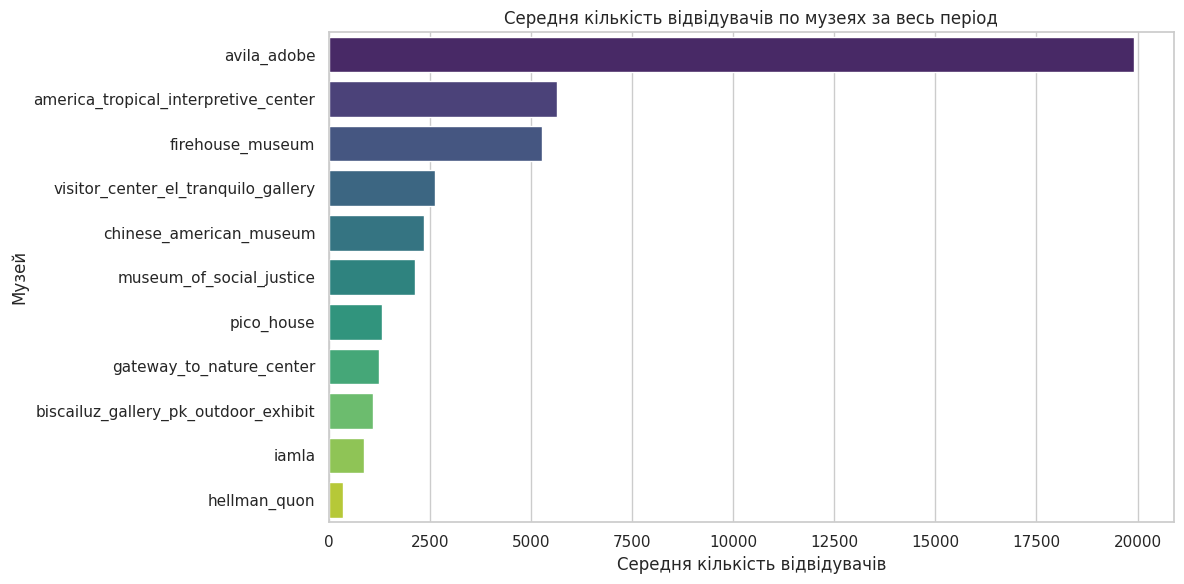

In [16]:
plt.figure(figsize=(12, 6))

# Формуємо датафрейм із середніми значеннями
mean_visitors_df = mean_visitors.reset_index()
mean_visitors_df.columns = ['museum', 'mean_visitors']
mean_visitors_df = mean_visitors_df.sort_values(by='mean_visitors', ascending=False)

sns.barplot(data=mean_visitors_df, x='mean_visitors', y='museum', palette='viridis')
plt.title('Середня кількість відвідувачів по музеях за весь період')
plt.xlabel('Середня кількість відвідувачів')
plt.ylabel('Музей')
plt.tight_layout()
plt.show()

Висновки до Завдання 1
Якість даних: Набір містить 85 записів, що охоплюють період з 2014 по 2021 рік. Дублікатів не виявлено, проте присутня велика кількість пропусків (NaN) у новіших чи менш популярних музеях (наприклад, Gateway to Nature Center чи Hellman Quon), оскільки дані для них почали збирати пізніше.

Аналіз популярності: Найбільш відвідуваним музеєм є Avila Adobe (в середньому понад 19 900 відвідувачів на місяць).

Сезонність: У 2015 році найвищий пік відвідуваності по всіх музеях спостерігався у травні (May), а найнижчий – у лютому (February). Цю тенденцію також підтверджує порівняння сезонів для музею Avila Adobe у 2018 році: влітку (66 122 відвідувачі) музей мав значно більшу популярність порівняно з зимовими місяцями (48 705 відвідувачів).

Кореляція у 2016 році: Аналіз показав, що впродовж 2016 року більшість музеїв мали слабку або негативну кореляцію з плином часу (відвідуваність до кінця року знижувалась або стагнувала).

Завдання 2. Датасет "Пінгвіни"

Завантаження та вивід даних "Пінгвінів"

In [18]:
# Завантаження датасету з пінгвінами
df_penguins = pd.read_csv('penguins_lter.csv')

# Виведення перших рядків
display(df_penguins.head())

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN


5 графіків Seaborn для датасету "Пінгвіни"

1: Scatterplot

['studyName', 'Sample_Number', 'Species', 'Region', 'Island', 'Stage', 'Individual_ID', 'Clutch_Completion', 'Date_Egg', 'Culmen_Length_mm', 'Culmen_Depth_mm', 'Flipper_Length_mm', 'Body_Mass_g', 'Sex', 'Delta_15_N_o_oo', 'Delta_13_C_o_oo', 'Comments']


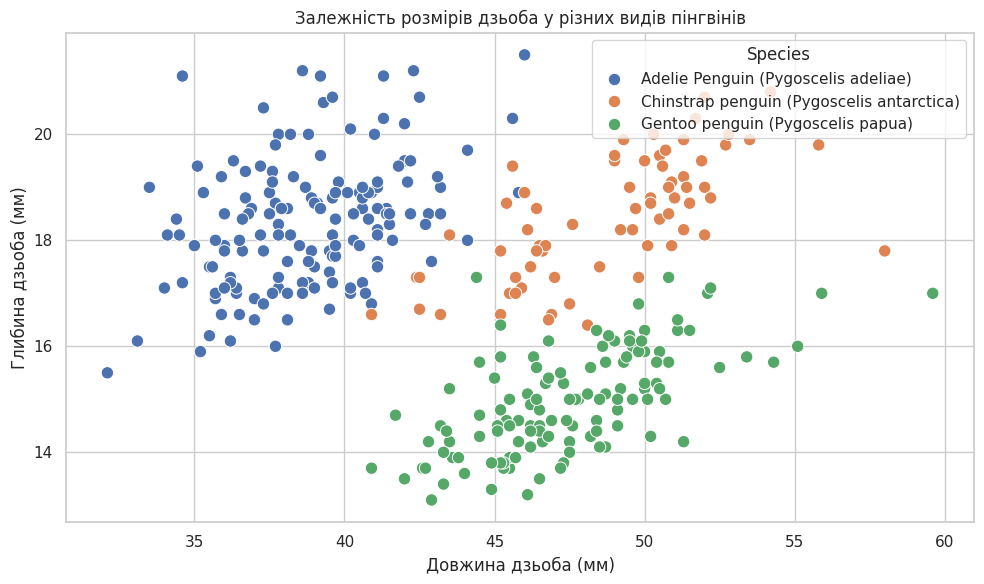

In [25]:
import re

df_penguins.columns = [re.sub(r'[^a-zA-Z0-9]', '_', col).strip('_') for col in df_penguins.columns]
df_penguins.columns = [re.sub(r'_+', '_', col) for col in df_penguins.columns]

print(df_penguins.columns.tolist())
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_penguins, x='Culmen_Length_mm', y='Culmen_Depth_mm', hue='Species', s=80)
plt.title('Залежність розмірів дзьоба у різних видів пінгвінів')
plt.xlabel('Довжина дзьоба (мм)')
plt.ylabel('Глибина дзьоба (мм)')
plt.tight_layout()
plt.show()

Histplot (Розподіл маси тіла)

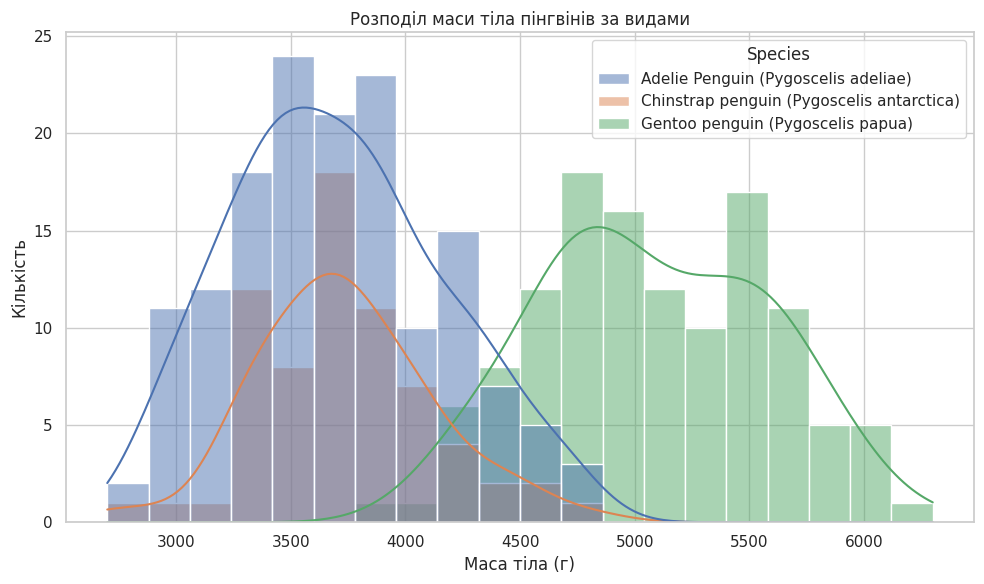

In [26]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_penguins, x='Body_Mass_g', hue='Species', kde=True, bins=20)
plt.title('Розподіл маси тіла пінгвінів за видами')
plt.xlabel('Маса тіла (г)')
plt.ylabel('Кількість')
plt.tight_layout()
plt.show()

Boxplot (Довжина ласт за видами)

/tmp/ipykernel_5887/1587730167.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_penguins, x='Species', y='Flipper_Length_mm', palette='Set2')


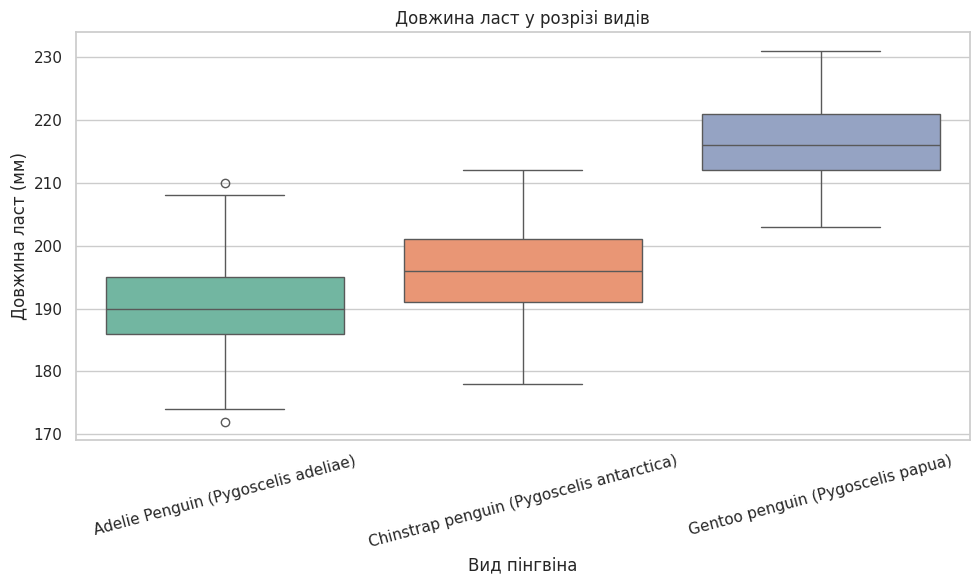

In [27]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_penguins, x='Species', y='Flipper_Length_mm', palette='Set2')
plt.title('Довжина ласт у розрізі видів')
plt.xlabel('Вид пінгвіна')
plt.ylabel('Довжина ласт (мм)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Violinplot (Маса тіла на різних островах)

/tmp/ipykernel_5887/1302594824.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_penguins, x='Island', y='Body_Mass_g', palette='Set3')


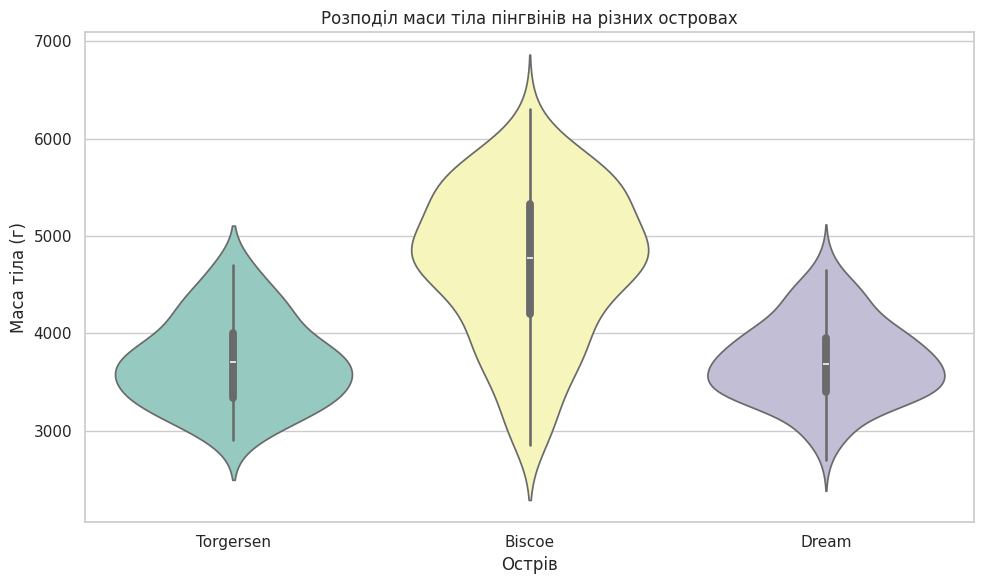

In [28]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_penguins, x='Island', y='Body_Mass_g', palette='Set3')
plt.title('Розподіл маси тіла пінгвінів на різних островах')
plt.xlabel('Острів')
plt.ylabel('Маса тіла (г)')
plt.tight_layout()
plt.show()

Barplot (Середня довжина дзьоба по статі та виду)

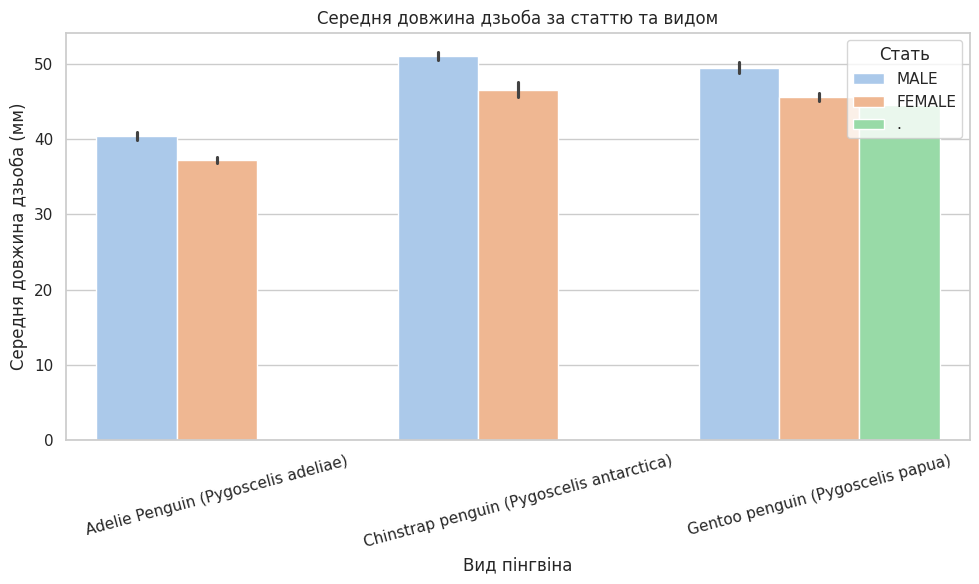

In [29]:
plt.figure(figsize=(10, 6))
# Видаляємо пропуски в колонці Sex для коректного відображення
df_penguins_clean = df_penguins.dropna(subset=['Sex'])

sns.barplot(data=df_penguins_clean, x='Species', y='Culmen_Length_mm', hue='Sex', palette='pastel')
plt.title('Середня довжина дзьоба за статтю та видом')
plt.xlabel('Вид пінгвіна')
plt.ylabel('Середня довжина дзьоба (мм)')
plt.xticks(rotation=15)
plt.legend(title='Стать')
plt.tight_layout()
plt.show()

Висновок (Завдання 2):

Фізичні відмінності: Вид Gentoo є найбільшим (найбільша маса тіла та найдовші ласти). Adelie та Chinstrap значно дрібніші і схожі за масою, але Chinstrap легко впізнати за помітно довшим дзьобом.

Розподіл по островах: Найважчі пінгвіни (переважно Gentoo) живуть на острові Biscoe. На інших островах переважають дрібніші види.

Статевий диморфізм: У всіх трьох видів самці стабільно більші за самок (зокрема, мають довші і глибші дзьоби).

Досліджені параметри (розміри дзьоба, довжина ласт і маса) є чудовими маркерами, які дозволяють чітко розрізняти ці три види пінгвінів між собою.